## *Importing dataset*

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df = df.drop(['CustomerID'], axis=1)
df.duplicated().any(), df.isnull().sum().any(), f"No.of Customers: {df.shape[0]}"

(np.False_, np.False_, 'No.of Customers: 200')

## *EDA*

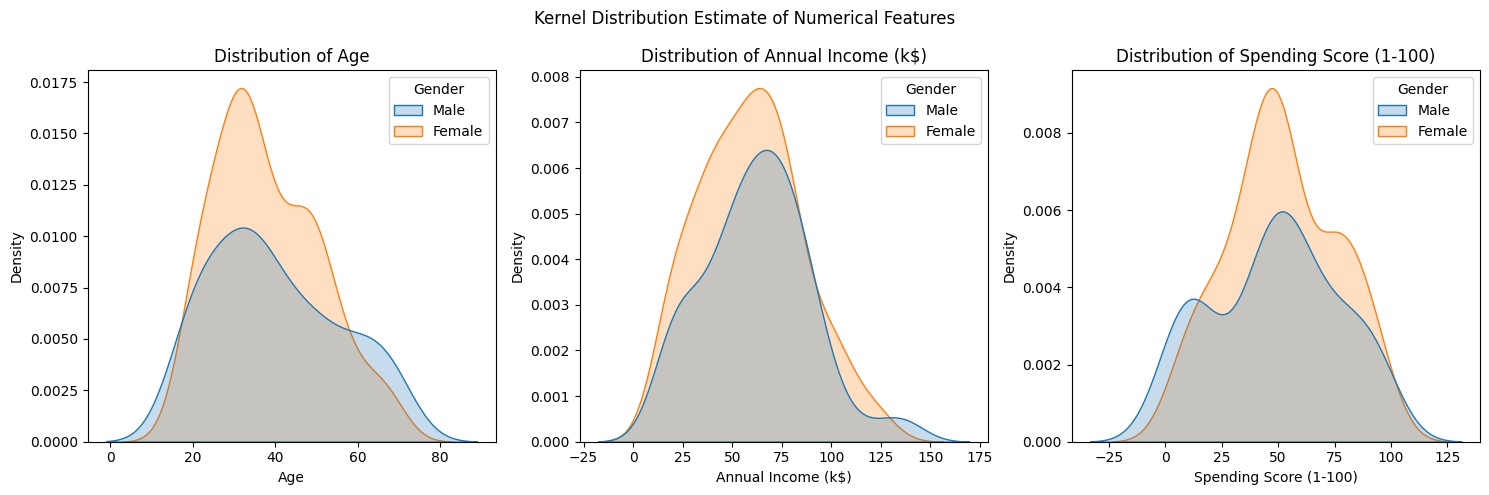

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

to_dist = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
fig,ax = plt.subplots(1,3, figsize=(15,5))
for i,col in enumerate(to_dist):
    sns.kdeplot(data=df, x=col, ax=ax[i], hue="Gender", fill=True)
    ax[i].set_title(f"Distribution of {col}")
fig.suptitle("Kernel Distribution Estimate of Numerical Features")
plt.tight_layout()
plt.show()

In [4]:
import plotly.express as px
%matplotlib inline
import plotly.io as pio
pio.renderers.default = "kaggle"

counts = df['Gender'].value_counts()
fig = px.pie(names=counts.index, values=counts.values)
fig.update_traces(textinfo="label+percent", insidetextorientation="radial")
fig.update_layout(height=400, width=400, title_x=0.5, title_text="Gender label distribution", 
                  title_font_size=20, title_font_color="darkblue")
fig.show()

## *K-Means Clustering*

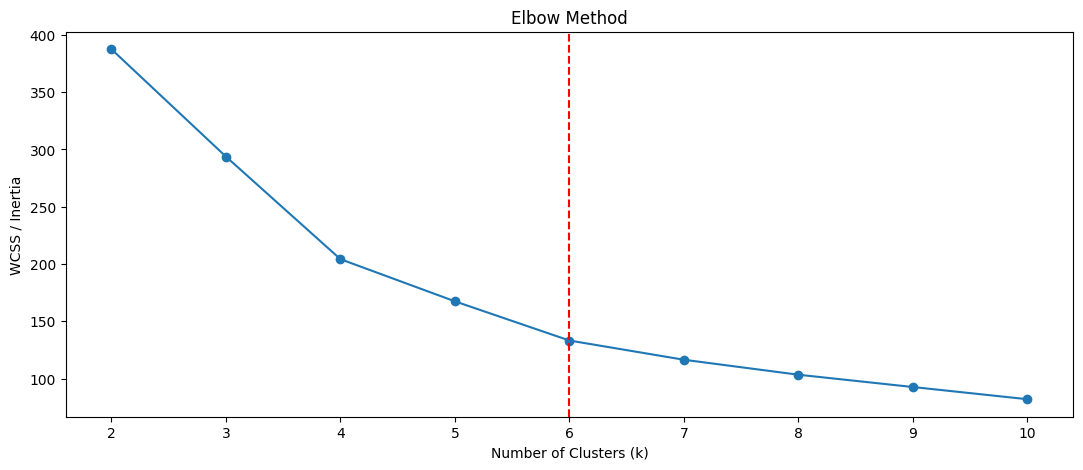

In [5]:
import numpy as np
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score

num_cols = df.select_dtypes(include="number")
num_cols_sc = (num_cols - num_cols.mean())/ num_cols.std()
inertias = []
sil_scores = []
n_k = np.arange(2,11).tolist()
for k in n_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    clusters = km.fit_predict(num_cols_sc)
    score = silhouette_score(num_cols_sc, clusters)
    inertias.append(km.inertia_)
    sil_scores.append(score)

optimal_k = n_k[np.argmax(sil_scores)]

plt.figure(figsize=(13,5))
plt.plot(n_k, inertias, marker="o")
plt.axvline(x=optimal_k, color="red", linestyle="--", label=f"Optimal K = {optimal_k}")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.show()

In [6]:
km = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)   
df["Cluster"] = km.fit_predict(num_cols_sc)
df["Cluster"] = df.Cluster.astype("category")

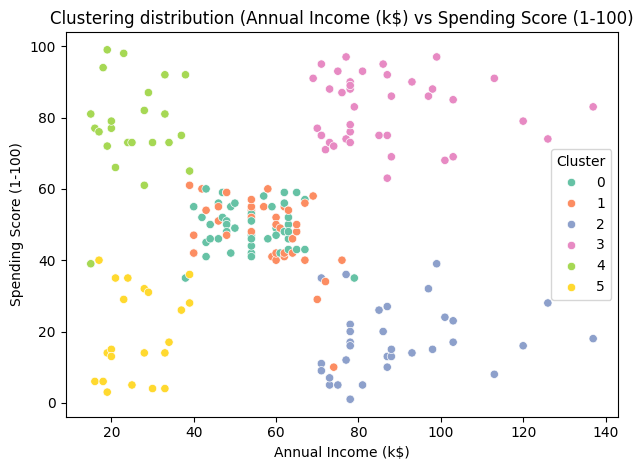

In [7]:
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Cluster", palette="Set2")
plt.title(f"Clustering distribution (Annual Income (k$) vs Spending Score (1-100)")
plt.tight_layout()
plt.show()

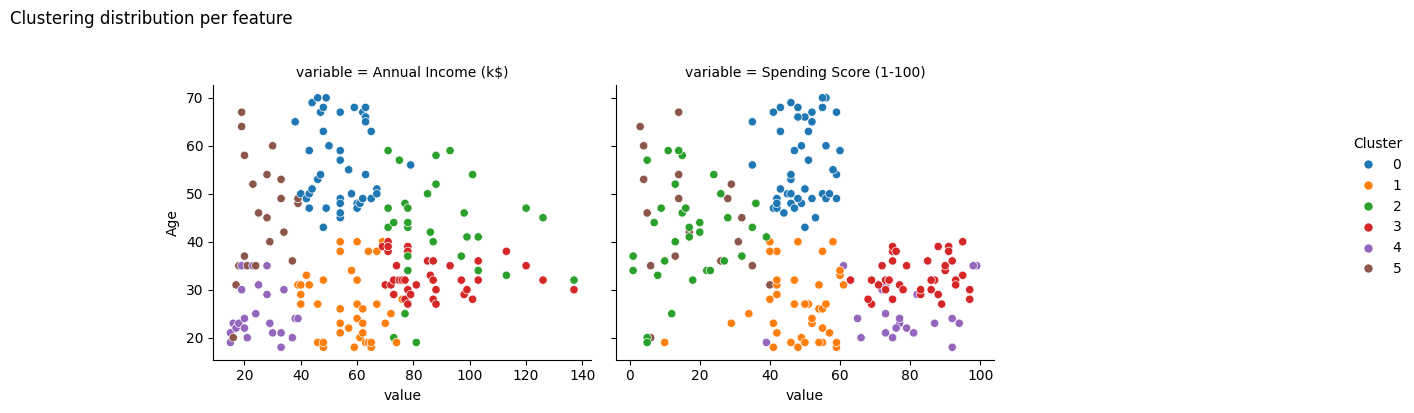

In [8]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]

sns.relplot(x="value", y= "Age", hue="Cluster", col="variable",
    height=4, aspect=1, facet_kws={'sharex': False}, col_wrap=3,
    data=df.melt(
        value_vars=features, id_vars=["Age", "Cluster"],),);
plt.suptitle("Clustering distribution per feature", x=0, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
report = pd.DataFrame({
    "Customer ID":df.index+1,
    "Cluster": df["Cluster"]
}).reset_index(drop=True)
report.iloc[::15]

,Customer ID,Cluster
0,1,4
15,16,4
30,31,5
45,46,4
60,61,0
75,76,1
90,91,0
105,106,1
120,121,1
135,136,3
